In [1]:
import torch
from pathlib import Path
from pydicom import dcmread
from PIL import Image
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from joblib import Parallel, delayed
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import albumentations as A
from functools import partial
from torchvision import transforms
import random

### Download the dataset form kaggle

In [2]:
from dotenv import load_dotenv
from kaggle.api.kaggle_api_extended import KaggleApi

# Load credentials
load_dotenv()
os.environ["KAGGLE_USERNAME"] = os.getenv("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = os.getenv("KAGGLE_KEY")

# Authenticate
api = KaggleApi()
api.authenticate()

'''
### DO this for the Public dataset (uplaoded by users)

# Example dataset download
api.dataset_download_files(
    "zynicide/wine-reviews",  # dataset path from Kaggle URL
    path="./data",
    unzip=True
)
print("Download complete")
''' 
 
# DO this is when doanlwoding a competition dataset
# Competition name
competition_name = "rsna-pneumonia-detection-challenge"

# # List files properly
# files = api.competition_list_files(competition_name)
# # Prints out all the available files (kinda)
# print("Available files:")
# for f in files.files:  # <-- use .files here
#     print(f.name)

# Download all files and unzip
api.competition_download_files(
    competition_name,
    path="./data/",
)

print("Competition data downloaded successfully!")

Competition data downloaded successfully!


### Unzip the downloaded files

In [3]:
import zipfile

zip_path = './data/rsna-pneumonia-detection-challenge.zip'
extract_dir = './data/pneumonia_dataset'

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("./data/pneumonia_dataset")

### Brief overview of how the data files are present in the RSNA Pneumonia Dataset.

* There are two data files:
- `stage_2_train_images`: All the training images. It has labels files too. (i.e: `stage_2_train_labels.csv` and `stage_2_detailed_class_info.csv`).
- `stage_2_test_images`: All the test images. Does not have lables files. Since RSNA Pneumonia Dataset is a competition dataset. We are supposed to inference these test images on our model and submit a prediction label files in the format of `stage_2_sample_submission.csv`.

* There are two lables files:
- `stage_2_train_labels.csv`: This file contains data labels corresponding to patientId. `0` for `No pneumonia` and `1` for case of `Pneumonia`. The Bbox Data labels only present for label `1` (Pneumonia present). Bbox Data empty for label `0` (No Pneumonia)
- `stage_2_detailed_class_info.csv`: It contains detailed data labels of `Lung Opacity`, `No Lung Opacity/Not Normal`, and `Normal`.
```
RSNA Pneumonia Detection - (3-Class Label Explanation):
* 'Lung Opacity'                 --> Pneumonia or similar lung opacity (positive case)
* 'Normal'                       --> Completely normal chest X-ray (no abnormal findings)
* 'No Lung Opacity / Not Normal' --> Abnormal chest X-ray, but NOT pneumonia (e.g., cardiomegaly, effusion, etc.)
This labeling helps distinguish pneumonia from both normal and other non-pneumonia abnormalities.
```

### Load the label file with bbox labels and detail_class_info label file 

In [4]:
# File path of the labels from the working data and convert the csv file into a pandas DataFrame

label_file_path = 'data/pneumonia_dataset/stage_2_train_labels.csv'

label_file_df = pd.read_csv(label_file_path)
class_info_df = pd.read_csv('data/pneumonia_dataset/stage_2_detailed_class_info.csv')

In [5]:
# concat the two dataframe on the basis of `patientId`
df = pd.concat([label_file_df, class_info_df['class']], axis=1)

In [6]:
df.sample(10)

,patientId,x,y,width,height,Target,class
18003,aafecca2-fefc-48e6-be48-a34488e06cbb,62.0,200.0,269.0,631.0,1,Lung Opacity
4553,3fb5525f-edfa-4217-81f9-df59b3e94135,NaN,NaN,NaN,NaN,0,Normal
2318,312920e7-f9a9-4064-aa35-96b805637bcc,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
25124,e14f7f94-baf7-4dea-b3e6-d69b29576e3d,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
26397,eb961991-d205-4a3b-9a8b-93707f4298c6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
2384,31970b0a-818f-4e1e-8c75-19dec06abfa5,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
11605,784a3ed0-2565-430f-819f-f713e1775344,620.0,509.0,178.0,241.0,1,Lung Opacity
3994,3c072590-e9e8-4ac2-b9e7-dd1776e2a537,235.0,490.0,168.0,296.0,1,Lung Opacity
245,063a4fc6-ef5d-4370-8b0b-c2752a4c905c,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
16020,9b76795f-c6ee-4b29-80ed-88a66910a784,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientId  30227 non-null  str    
 1   x          9555 non-null   float64
 2   y          9555 non-null   float64
 3   width      9555 non-null   float64
 4   height     9555 non-null   float64
 5   Target     30227 non-null  int64  
 6   class      30227 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 1.6 MB


### Handle Missing Data
The `0` or `no pneumonia` class has no bbox data so we only need to handle missing data for the `1` or `pneumonia` class

In [8]:
df

,patientId,x,y,width,height,Target,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,Lung Opacity
...,...,...,...,...,...,...,...
30222,c1ec14ff-f6d7-4b38-b0cb-fe07041cbdc8,185.0,298.0,228.0,379.0,1,Lung Opacity
30223,c1edf42b-5958-47ff-a1e7-4f23d99583ba,NaN,NaN,NaN,NaN,0,Normal
30224,c1f6b555-2eb1-4231-98f6-50a963976431,NaN,NaN,NaN,NaN,0,Normal
30225,c1f7889a-9ea9-4acb-b64c-b737c929599a,570.0,393.0,261.0,345.0,1,Lung Opacity


In [9]:
# The `x`, `y`, `width` and `height` columns for Target 0 are excepted to have missing value indicating no bbox
missing_data = df.isna().sum()
print(f'Number of missing values per columns:\n{missing_data}')

### The missing value down here for (x, y, width, height) is because the data class with '0' Target (no pneumonia) have no bounding boxes label data.

Number of missing values per columns:
patientId        0
x            20672
y            20672
width        20672
height       20672
Target           0
class            0
dtype: int64


In [10]:
# Check missing data exclusisvley for Target class 1
present_df = df[df.Target == 1]
missing_data_pres = present_df.isna().sum()
print(f'Number of missing values per columns:\n{missing_data_pres}')

Number of missing values per columns:
patientId    0
x            0
y            0
width        0
height       0
Target       0
class        0
dtype: int64


In [11]:
# Total bbox annotations, Total unique images with bbox annotations
print(f'Total BBOX Annotations: {len(present_df)}')
print(f'Total Unique Images with BBOX Annotations: {len(present_df.drop_duplicates('patientId'))}')

Total BBOX Annotations: 9555
Total Unique Images with BBOX Annotations: 6012


### Check the class Distribution in the data

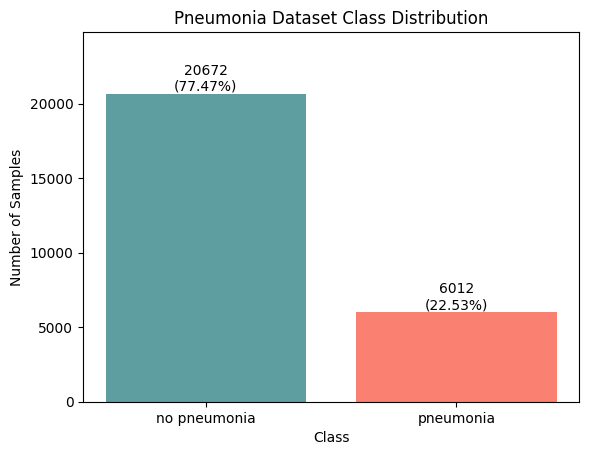

In [12]:
# Number of Data samples with pneumonia and without pneumonia

counts = df.drop_duplicates('patientId')['Target'].value_counts()

# num_no_pneumonia = counts[0]
# num_pneumonia = counts[1]

data_class = {
    'no pneumonia': int(counts.get(0, 0)),
    'pneumonia': int(counts.get(1, 0))
}

total = sum(data_class.values())


bars = plt.bar(data_class.keys(), data_class.values(), color=['cadetblue', 'salmon'])
plt.bar_label(bars, labels=[f"{value}\n({value/total*100:.2f}%)" for value in data_class.values()])
plt.ylim(0, 1.2*max(data_class.values()))
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Pneumonia Dataset Class Distribution')
plt.show()

In [13]:
# Create a dictionary with all the classes and their corresponding value(occurance in the label)
# count = df.drop_duplicates('patientId')['class'].value_counts()
count = df['class'].value_counts()

data_class_detail = count.keys()

data_num_obj = {}


for x in range(len(count)):
    entry = {data_class_detail[x]: count.iloc[x].item()}
    data_num_obj.update(entry)

data_num_obj

{'No Lung Opacity / Not Normal': 11821, 'Lung Opacity': 9555, 'Normal': 8851}

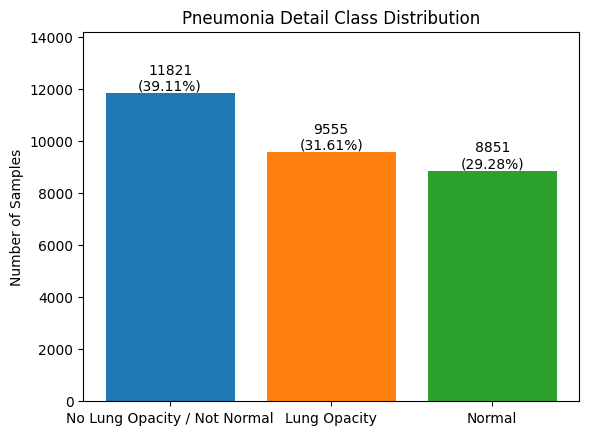

In [14]:
color = sns.color_palette('tab10', n_colors=len(data_num_obj))

total = sum(count.values).item()

bar = plt.bar(data_num_obj.keys(), data_num_obj.values(), color=color)

plt.bar_label(bar, labels=[f'{values}\n({(values/total)*100:.2f}%)' for values in data_num_obj.values()])
plt.ylim(0, 1.2*max(data_num_obj.values()))
# plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Pneumonia Detail Class Distribution')
plt.show()

RSNA Pneumonia Detection - (3-Class Label Explanation):
* 'Lung Opacity'                 --> Pneumonia or similar lung opacity (positive case)
* 'Normal'                       --> Completely normal chest X-ray (no abnormal findings)
* 'No Lung Opacity / Not Normal' --> Abnormal chest X-ray, but NOT pneumonia (e.g., cardiomegaly, effusion, etc.)

This labeling helps distinguish pneumonia from both normal and other non-pneumonia abnormalities.

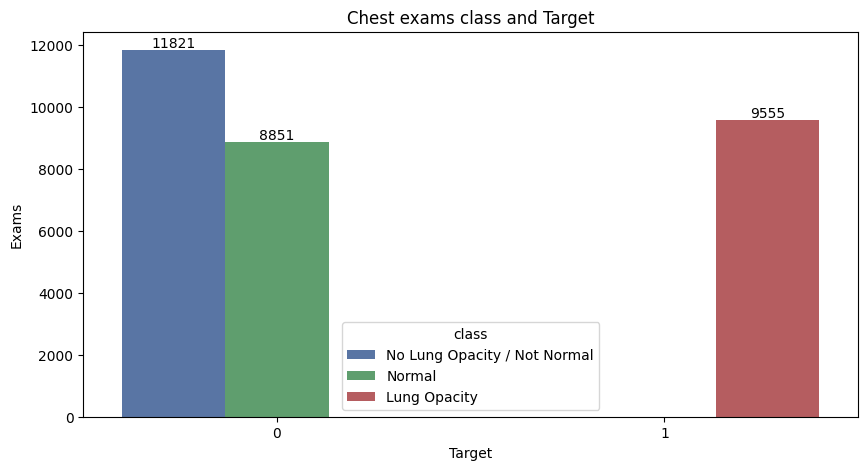

In [15]:
fig, ax = plt.subplots(nrows=1,figsize=(10,5))
tmp = df.groupby('Target')['class'].value_counts()
temp_df = pd.DataFrame(data={'Exams': tmp.values}, index=tmp.index).reset_index()
ax = sns.barplot(ax=ax,x ='Target', y='Exams',hue='class',data=temp_df, palette = ['#4C72B0', '#55A868', '#C44E52'])

for container in ax.containers:
    ax.bar_label(container, fmt='%d')


plt.title("Chest exams class and Target")
plt.show()

### DCM file and its Data Contents

In [16]:
Id = df.patientId[0]

dcm_file_path = f'data/pneumonia_dataset/stage_2_train_images/{Id}.dcm'
dcm_file_data = dcmread(dcm_file_path)
dcm_file_data

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.28530.1517874485.775526
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.28530.1517874485.775526
(0008,0020) Study Date                          DA: '19010101'
(0008,0030) Study Time                  

### `print_sample` To print the data images with bbox(if any)

In [17]:
class_str = list(data_class.keys())

def print_sample(label_df, sample_images, rows, columns):

    fig, axes = plt.subplots(rows, columns, figsize=(9, 9))
    axes = axes.flatten() # flatten the axis form 2D to 1D making it easier to index over it

    total_subplots = rows * columns

    # print(sample_images)
    

    for idx in range(min(len(sample_images), total_subplots)): # Limit the display to just rows*columns images
        Id = sample_images.iloc[idx]
        dcm_file_path = f'data/pneumonia_dataset/stage_2_train_images/{Id}.dcm'
        dcm_file_data = dcmread(dcm_file_path)
        pixel_data = dcm_file_data.pixel_array

        
        axes[idx].imshow(pixel_data, cmap='grey')
        axes[idx].axis(False)

        # Get all the data columns for the instance of the Id
        all_instance = label_df[label_df['patientId'] == Id]
        class_label = all_instance.iloc[0].Target

        if  class_label == 1:
            
            for x in range(len(all_instance)):
                col_data = all_instance.iloc[x]
            
                # Print Bounding Box if the pneumonia present
                x, y, width, height, =  col_data.x, col_data.y, col_data.width, col_data.height
                rect = patches.Rectangle((x, y), width, height, facecolor='none', edgecolor='red', lw=2)
                axes[idx].add_patch(rect)

        # Set Title color according to class
        color = 'green' if class_label == 0 else 'red'

        # Set titel to the patient Id and the status of the present of pneumonia or not
        # axes[idx].set_title(f'Patient Id: {Id}, {class_label}', fontsize=9, color=color)
        axes[idx].set_title(f'{class_str[class_label]}', fontsize=12, color=color)

    plt.tight_layout()

    # Hide any unused subplots
    for j in range(len(sample_images), total_subplots):
        axes[j].axis('off')

#### When plotting the RSNA Pneumonia dataset bbox coordinates in the `matplotlib.patches.Rectangle()` no transformation of the coordinates is needed. (## RSNA coords → Rectangle: no transformation needed)
##### Even though `matplotlib.patches.Rectangle()` used bottom-left while RSNA Pneumonia dataset bbox coordinates are in top-left. Its because the `imshow` flips the y-axis.

`Rectangle(xy)` = **bottom-left** anchor (normal axes, y goes up)  
`imshow` = **flips y-axis** (y goes down, origin at top). these cancel out, so `xy` behaves as **top-left** visually.

RSNA labels are also **top-left, y-down** — so they plug in directly.

```python
rect = patches.Rectangle(
    (row['x'], row['y']),  # top-left, no transformation needed
    row['width'],
    row['height'],
)
```

### Print some of the pneumonia and no pneumonia images form the dataset

In [18]:
pneu_df = df[df.Target == 1]
no_pneu_df = df[df.Target == 0]

pneu_present_sample = pneu_df.sample(9).patientId
pneu_not_present_sample = no_pneu_df.sample(9).patientId

# all_class_sample = pd.concat([pneu_present_sample, pneu_not_present_sample])

# all_class_sample = all_class_sample.sample(frac=1)

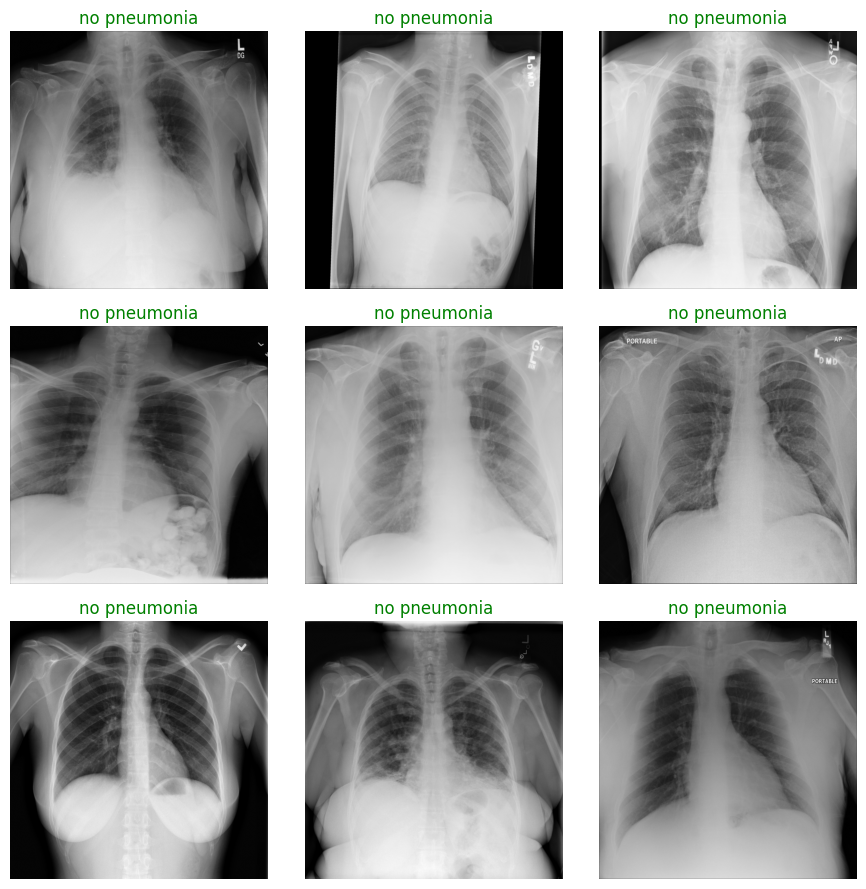

In [19]:
print_sample(label_df=df, sample_images=pneu_not_present_sample, rows=3, columns=3)

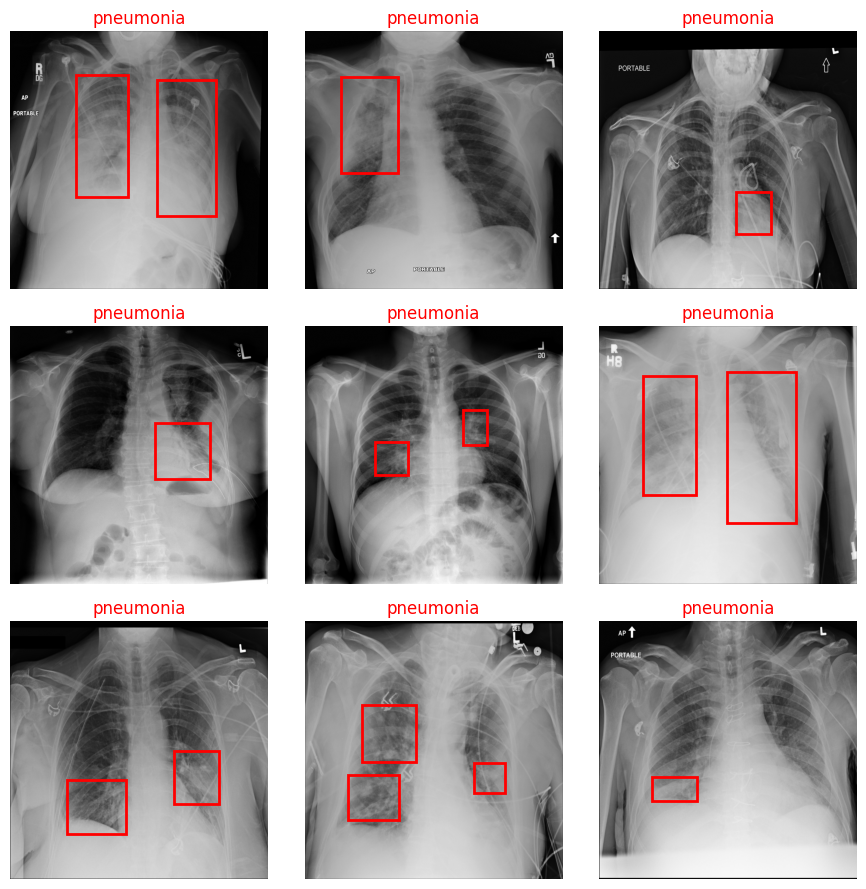

In [20]:
print_sample(label_df = df, sample_images=pneu_present_sample, rows=3, columns=3)

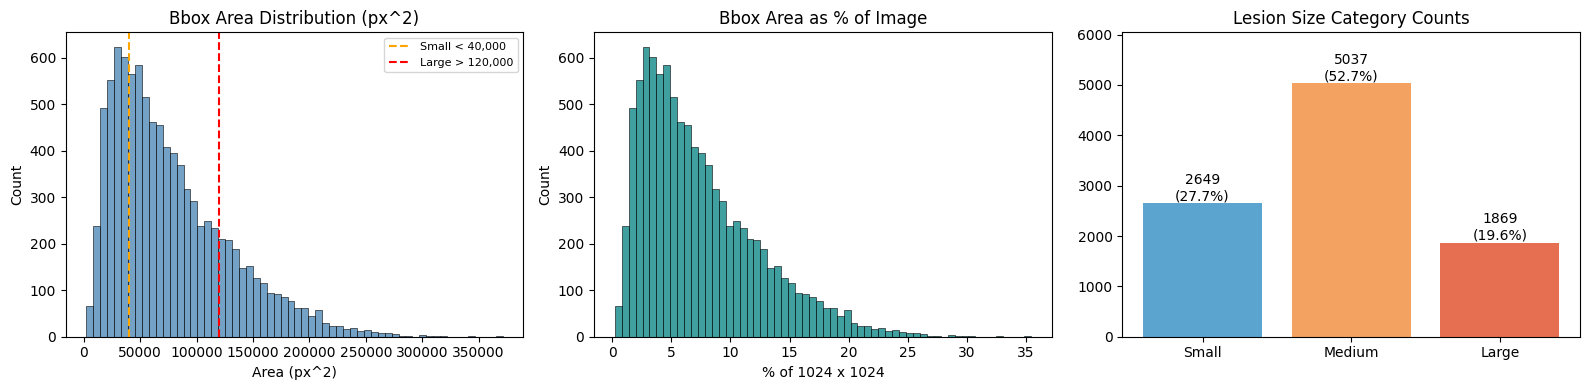

Lesion count per patient:
bbox_count
1    2614
2    3266
3     119
4      13
Name: count, dtype: int64


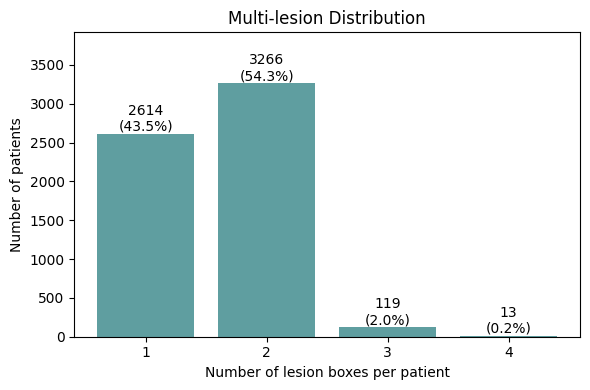


Bbox area summary (px^2):
count      9555.0
mean      77523.0
std       51808.0
min        2320.0
25%       37536.0
50%       64829.0
75%      106492.0
max      371184.0
Name: bbox_area, dtype: float64

Bbox area summary (% of image):
count    9555.00
mean        7.39
std         4.94
min         0.22
25%         3.58
50%         6.18
75%        10.16
max        35.40
Name: bbox_area_percent, dtype: float64


In [21]:
# ____________________________________________________
# Bbox Size Analysis

# Get all the df data with Target 1 (Pneumonia present - so they will have bbox data)
target_df = df[df['Target'] == 1].copy()

# Raw pixel area of each bbox
target_df['bbox_area'] = target_df['width'] * target_df['height']

# bbox as a percentage of the full 1024*1024 image
target_df['bbox_area_percent'] = (target_df['bbox_area']/ (1024 * 1024)) * 100

# size catergory thresholds
SMALL_THRESH = 40_000   # px^2
LARGE_THRESH = 120_000   # px^2


def size_category(area):
    if area < SMALL_THRESH:
        return 'Small'
    elif area <= LARGE_THRESH:
        return 'Medium'
    else:
        return 'Large'
    
target_df['lesion_size'] = target_df['bbox_area'].apply(size_category)


# ____________________________________________________________________
# Overall Size Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw Area Histogram
sns.histplot(target_df['bbox_area'], bins=60, ax=axes[0], color='steelblue')
axes[0].axvline(SMALL_THRESH, color='orange', linestyle='--', label=f'Small < {SMALL_THRESH:,}')
axes[0].axvline(LARGE_THRESH, color='red', linestyle='--', label=f'Large > {LARGE_THRESH:,}')
axes[0].set_title('Bbox Area Distribution (px^2)')
axes[0].set_xlabel('Area (px^2)')
axes[0].legend(fontsize=8)

# % of image area histogram
sns.histplot(target_df['bbox_area_percent'], bins=60, ax=axes[1], color='teal')
axes[1].set_title('Bbox Area as % of Image')
axes[1].set_xlabel('% of 1024 x 1024')

# Size category bar chart
size_counts = target_df['lesion_size'].value_counts().reindex(['Small', 'Medium', 'Large'])
total = size_counts.sum()
bars = axes[2].bar(size_counts.index, size_counts.values, 
                   color=['#5BA4CF', '#F4A261', '#E76F51'])
axes[2].bar_label(bars, labels=[f"{v}\n({v/total*100:.1f}%)" for v in size_counts.values])
axes[2].set_ylim(0, size_counts.max() * 1.2)
axes[2].set_title('Lesion Size Category Counts')

plt.tight_layout()
plt.show()


# ______________________________________________________
### Multi-Bbox: How many patients have 2+ lesions?
bbox_per_patient = target_df.groupby('patientId').size().reset_index(name='bbox_count')

print('Lesion count per patient:')
print(bbox_per_patient['bbox_count'].value_counts().sort_index())


fig, ax = plt.subplots(figsize=(6, 4))
counts = bbox_per_patient['bbox_count'].value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color='cadetblue')
ax.bar_label(bars, labels=[f'{v}\n({v/counts.sum()*100:.1f}%)' for v in counts.values])
ax.set_xlabel('Number of lesion boxes per patient')
ax.set_ylabel('Number of patients')
ax.set_title('Multi-lesion Distribution')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()



# ___________________________________________________
# Summary Stats
print('\nBbox area summary (px^2):')
print(target_df['bbox_area'].describe().round(0))

print('\nBbox area summary (% of image):')
print(target_df['bbox_area_percent'].describe().round(2))

### Check the distribution of disease(for case that have pneumonia) by Age and Sex and plot a histogram to show the distribtuion across these Variables(age and sex)

In [22]:
dcm_metadata = df.patientId
dcm_metadata = pd.DataFrame(dcm_metadata)

Id_list = dcm_metadata.patientId

In [23]:
# Use parallel processing via `joblib` library to read the dcm meta-data faster

def patient_age_data(Id):
    dcm_file_path = f'data/pneumonia_dataset/stage_2_train_images/{Id}.dcm'
    dcm_file = dcmread(dcm_file_path, stop_before_pixels=True)
    return int(dcm_file.PatientAge)

def patient_sex_data(Id):
    dcm_file_path = f'data/pneumonia_dataset/stage_2_train_images/{Id}.dcm'
    dcm_file = dcmread(dcm_file_path, stop_before_pixels=True)
    return dcm_file.PatientSex

def patient_view_data(Id):
    dcm_file_path = f'data/pneumonia_dataset/stage_2_train_images/{Id}.dcm'
    dcm_file = dcmread(dcm_file_path, stop_before_pixels=True)
    return  dcm_file.ViewPosition

parallel_obj = Parallel(n_jobs=-1) # n_jobs='-1' if we want to use all the available cpu cores

# return age and sex data list from 
age_data = parallel_obj(delayed(patient_age_data)(Id) for Id in Id_list) 
sex_data = parallel_obj(delayed(patient_sex_data)(Id) for Id in Id_list)
view_data = parallel_obj(delayed(patient_view_data)(Id) for Id in Id_list)

In [24]:
# assign the age and sex data list to the age and sex columns
dcm_metadata['age'] = age_data
dcm_metadata['sex'] = sex_data
dcm_metadata['view'] = view_data

# Check if there are any missing values
dcm_metadata.isna().sum()

patientId    0
age          0
sex          0
view         0
dtype: int64

In [25]:
# merge the inital df and the metadata df into one 'df_metadata' on 'patientId'
df_metadata = pd.concat([df, dcm_metadata['age'], dcm_metadata['sex'], dcm_metadata['view']], axis=1)

In [26]:
# Check for any missing values in the data
df_metadata.isna().sum()

patientId        0
x            20672
y            20672
width        20672
height       20672
Target           0
class            0
age              0
sex              0
view             0
dtype: int64

In [27]:
# Check unique values in the age data 
age_histogram_data = df_metadata.drop_duplicates('patientId').age
age_histogram_data.unique()

array([ 51,  48,  19,  28,  32,  54,  78,  75,  59,  63,   6,  23,  70,
        58,  36,  43,  21,  52,  60,  71,  50,  38,  47,  67,  44,  40,
        56,  53,  31,  49,  14,  68,  42,  57,  41,  62,  15,  29,   2,
        39,  13,  34,  61,  35,  66,  30,   7,   3,  37,  46,  76,  27,
        20,  64,  65,  45,  73,  69,  16,  24,  17,  77,  25,  22,  55,
        74,  18,  33,   9,  87,  26,  10,  12,  86,  72,  79,  83,  81,
        11,  80,  85,   8,  82,   5,  84,  90,  88,   4,  89, 148,   1,
        92, 151, 153,  91, 150, 155])

In [28]:
# since we have age like 155, 151..which dosen't make sense we have to remove these outliers
age_histogram_data.describe()

Q1 = age_histogram_data.quantile(0.25)
Q2 = age_histogram_data.quantile(0.5)
Q3 = age_histogram_data.quantile(0.75)

IQR = Q3 - Q1

print(Q1, Q2, Q3, IQR)

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit, upper_limit)

34.0 49.0 59.0 25.0
-3.5 96.5


In [29]:
# all the columns with the outlier age data
df_metadata[(df_metadata.age > upper_limit)|(df_metadata.age < lower_limit)]

,patientId,x,y,width,height,Target,class,age,sex,view
3921,3b8b8777-a1f6-4384-872a-28b95f59bf0d,NaN,NaN,NaN,NaN,0,Normal,148,M,PA
11032,73aeea88-fc48-4030-8564-0a9d7fdecac4,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,151,F,PA
17213,a4e8e96d-93a6-4251-b617-91382e610fab,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,153,M,PA
26488,ec3697bd-184e-44ba-9688-ff8d5fbf9bbc,NaN,NaN,NaN,NaN,0,Normal,150,M,PA
27746,f632328d-5819-4b29-b54f-adf4934bbee6,NaN,NaN,NaN,NaN,0,Normal,155,F,PA


In [30]:
# new df with all the age outliers removed

no_age_outlier_df = df_metadata[(df_metadata.age > lower_limit)&(df_metadata.age < upper_limit)]
unique_values = no_age_outlier_df.age.unique()
unique_values.sort()
unique_values



# new df with all the age outliers removed

# no_age_outlier_df = df_metadata[df_metadata['age'].between(lower_limit, upper_limit)]
# unique_values = sorted(no_age_outlier_df['age'].unique().tolist()) 
# (unique_values[:20])

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92])

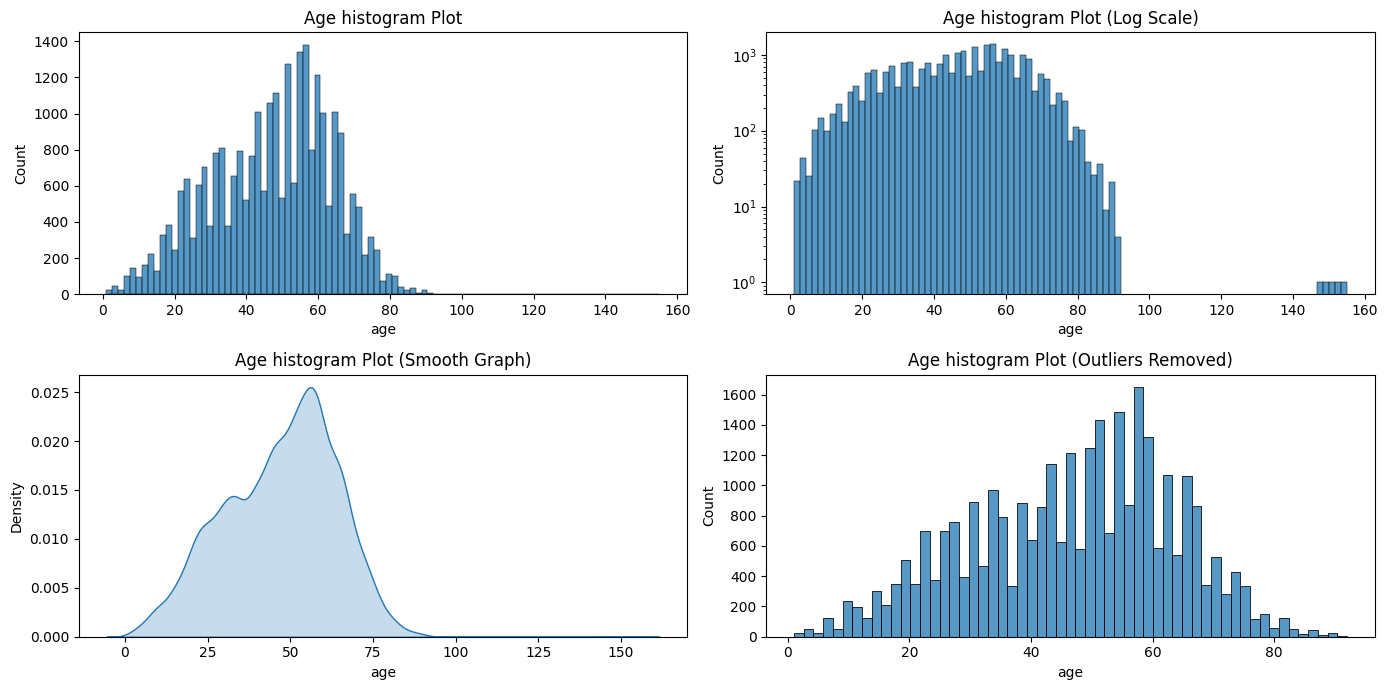

In [31]:
# Plot histograms for the age data

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()

sns.histplot(age_histogram_data, ax=axes[0])
axes[0].set_title('Age histogram Plot')

# frequncy data of the age is in log scale to visualize the less occuring age data
sns.histplot(age_histogram_data, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Age histogram Plot (Log Scale)')


sns.kdeplot(age_histogram_data, fill=True, ax=axes[2])
axes[2].set_title('Age histogram Plot (Smooth Graph)')

sns.histplot(no_age_outlier_df.age, ax=axes[3])
axes[3].set_title('Age histogram Plot (Outliers Removed)')

plt.tight_layout()

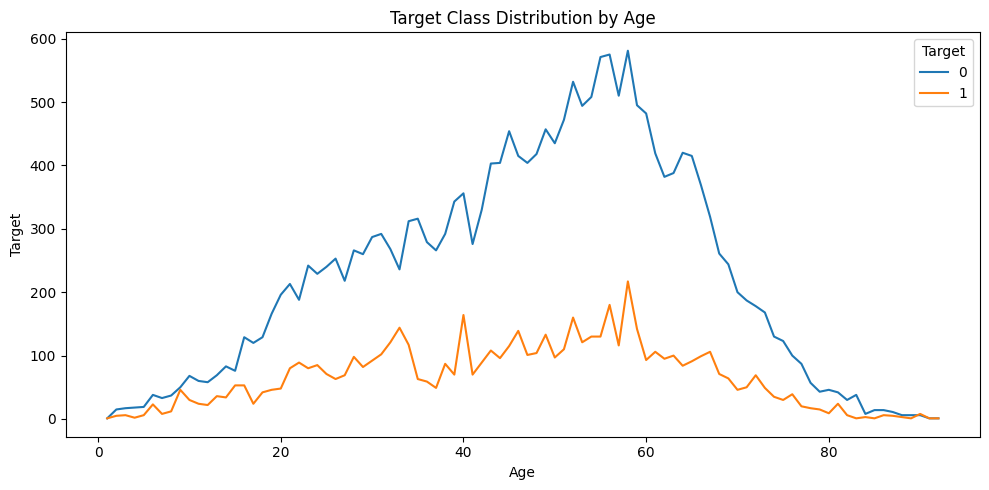

In [32]:
# Pneumonia Dataset Class distribution by Age
temp = no_age_outlier_df.drop_duplicates('patientId').groupby('age')['Target'].value_counts()

age_distribution = pd.DataFrame(data={'count': temp.values}, index=temp.index).reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=age_distribution, x='age', y='count', hue='Target')

plt.title('Target Class Distribution by Age')
plt.xlabel('Age')
plt.ylabel('Target')

plt.tight_layout()

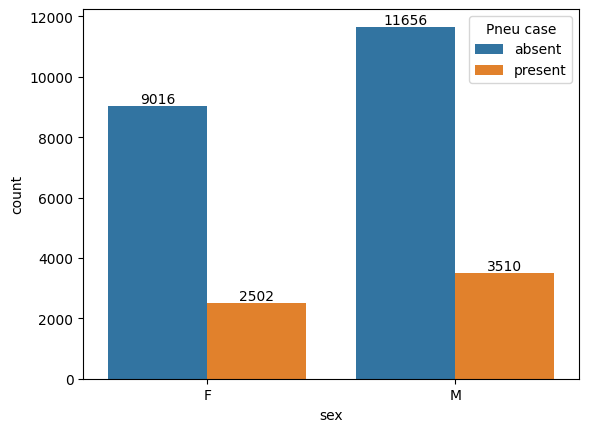

In [33]:
# Pneumonia Dataset Class distribution by Gender


# Drop duplicate patients, group by sex, then count how many patients in each sex group have Target = 0 or 1
tmp = df_metadata.drop_duplicates('patientId').groupby('sex')['Target'].value_counts()

# convet this droup by series to dataframe with proper values and index
data_fr = pd.DataFrame(data={'count': tmp.values}, index=tmp.index).reset_index()

# plot the bar with subclass/hue='Target' (0 or 1)
bar = sns.barplot(data=data_fr, x='sex', y='count', hue='Target', legend=True)
handles, labels = bar.get_legend_handles_labels()

plt.legend(handles=handles, labels=['absent', 'present'], title='Pneu case')

for container in bar.containers:
    bar.bar_label(container, fmt='%d')

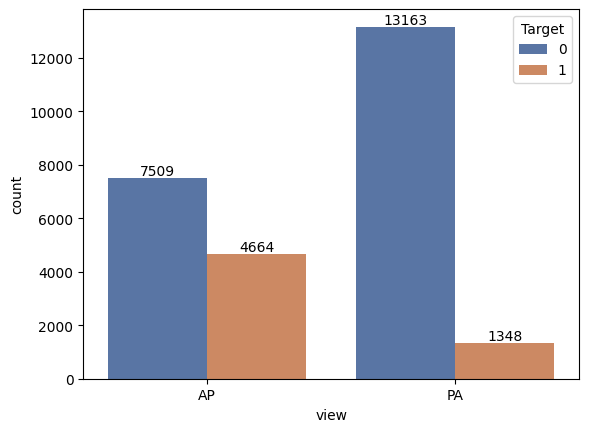

In [34]:
# Pneumonia Dataset Class distribution by View (PA vs AP plot)


# count = df.view.value_counts()
count = df_metadata.drop_duplicates('patientId').groupby('view')['Target'].value_counts()
view_count = pd.DataFrame(data={'count': count.values}, index=count.index).reset_index()

bar = sns.barplot(data=view_count, x='view', y='count', hue='Target', palette=["#4C72B0", "#DD8452"])
for container in bar.containers:
    bar.bar_label(container, fmt='%d')

### Heat map of the bbox presence across image data

Text(0.5, 1.0, 'Bounding Box HeatMap Overlay')

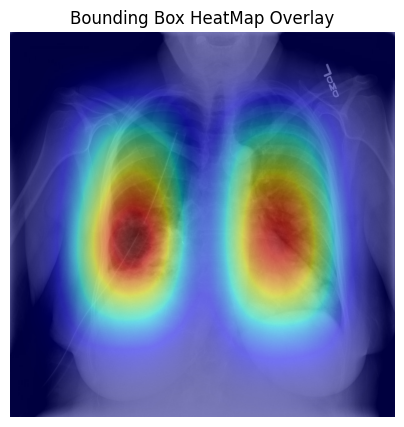

In [35]:
# Get all the labeled data rows (Target = 1) and plot the bbox into the heatmap

# get all the columns data with the bounding box values
target_data = df[df.Target == 1]
bbox_data = target_data.iloc[:, 1: 5]
bbox_data


# Load your image
image = cv2.imread('scan.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create an empty heatmap (same height and width as image)
heatmap = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

for index, box in bbox_data.iterrows():
    x, y, w, h = box
    x_min, y_min = int(x), int(y)
    x_max, y_max = int(x + w), int(y + h)
    
    # Add 1 to the heatmap area covered by this bbox
    heatmap[y_min:y_max, x_min:x_max] += 1


# Normalize heatmap to 0-1
heatmap /= np.max(heatmap)

# Optional: apply Gaussian blur for smoothness
heatmap = cv2.GaussianBlur(heatmap, (31,31), 0)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.axis(False)
plt.title('Bounding Box HeatMap Overlay')

### Normalize the bbox coordinates in the dataframe
### Normalize the x, y, width and height data (in range of 0 to 1)

In [36]:
# Get the height and width data of each image
# Nomralize the bbox data based on this height and width data of the image
# normalize only for the Target = '1' because bbox data is only present for data with pneumonia present

# Use parallel processing via `joblib` library to read the dcm meta-data faster

Id_list_no_dupli = Id_list.drop_duplicates()

def size_data(Id):
    dcm_file_path = f'data/pneumonia_dataset/stage_2_train_images/{Id}.dcm'
    dcm_file = dcmread(dcm_file_path, stop_before_pixels=True)
    row = dcm_file.Rows
    col = dcm_file.Columns
    return row, col


dim_data = parallel_obj(delayed(size_data)(Id) for Id in Id_list_no_dupli)

In [37]:
# convert the image dim meta-data form the dcm file into a dataframe....we attach this to the original dataframe and normalize the bbox values according to it......
# plan is to take the full height and width of the image size data and use that to normalize the images corresponding bbox data 
img_dim_df = pd.DataFrame(dim_data)
len(img_dim_df)

row = img_dim_df[0].unique()
col = img_dim_df[1].unique()
print(f'Unique values of Row size: {row}')
print(f'Unique values of Column size: {col}')

Unique values of Row size: [1024]
Unique values of Column size: [1024]


In [38]:
# But now we know that all the images in the dataset are in size 1024 * 1024
# So lets noramlize all the  bbox data values by dividing them by 1024
df_normalized = df.copy()

df_normalized['x'] = df_normalized['x'] / 1024
df_normalized['y'] = df_normalized['y'] / 1024
df_normalized['width'] = df_normalized['width'] / 1024
df_normalized['height'] = df_normalized['height'] / 1024

df_normalized

,patientId,x,y,width,height,Target,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,0.257812,0.148438,0.208008,0.370117,1,Lung Opacity
...,...,...,...,...,...,...,...
30222,c1ec14ff-f6d7-4b38-b0cb-fe07041cbdc8,0.180664,0.291016,0.222656,0.370117,1,Lung Opacity
30223,c1edf42b-5958-47ff-a1e7-4f23d99583ba,NaN,NaN,NaN,NaN,0,Normal
30224,c1f6b555-2eb1-4231-98f6-50a963976431,NaN,NaN,NaN,NaN,0,Normal
30225,c1f7889a-9ea9-4acb-b64c-b737c929599a,0.556641,0.383789,0.254883,0.336914,1,Lung Opacity


### YOLO Format Label Data in the DataFrame

In [39]:
# The RSNA Pneumonia Dataset label comes as 'x-min y-min width height'..... but the coordinates yolo label format is ' x_center y_center width height'

# so we need to convert this to yolo format and save in the dataframe

# YOLO LABEL FILE FORMAT: '<class_id> x_center y_center width height'

In [40]:
# the following is vectorized operations
# '''
# Vectorized operations = faster, cleaner, and more efficient code by working on entire arrays at once rather than 
# looping through elements.
# '''

# U wanna do the same here too. value should stay same ever after myltiple run of the shell. do like a dataframe copy and modify the data from that copy dataframe.

df_normalized_center = df_normalized.copy()

df_normalized_center.rename(columns={'x': 'x_center', 'y': 'y_center'}, inplace=True)
mask = df_normalized_center.Target == 1
df_normalized_center.loc[mask, 'x_center'] += df_normalized_center.loc[mask, 'width'] / 2
df_normalized_center.loc[mask, 'y_center'] += df_normalized_center.loc[mask, 'height'] / 2

df_normalized_center

,patientId,x_center,y_center,width,height,Target,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,0.361816,0.333496,0.208008,0.370117,1,Lung Opacity
...,...,...,...,...,...,...,...
30222,c1ec14ff-f6d7-4b38-b0cb-fe07041cbdc8,0.291992,0.476074,0.222656,0.370117,1,Lung Opacity
30223,c1edf42b-5958-47ff-a1e7-4f23d99583ba,NaN,NaN,NaN,NaN,0,Normal
30224,c1f6b555-2eb1-4231-98f6-50a963976431,NaN,NaN,NaN,NaN,0,Normal
30225,c1f7889a-9ea9-4acb-b64c-b737c929599a,0.684082,0.552246,0.254883,0.336914,1,Lung Opacity


### SPlit the Data into Train and Val Set and Test Set(Stratified Splitting based on Target and view labels)..... 

In [41]:
# Create a stratifiy_column that combines the data form the `Target` and `view`.............we will use this new column to stratigy the group into `train` and `val` so that both the set have balance of both 0 and 1 target class and PA and AP view class....meaning both the class values(Target and view) are distibuted uniformaly acroos both the `train` and `val` set

# NOTE: # If we want to stratify by multiple groups we can create a new columns class(combining these multiple groups) and straftiy on that new column

In [42]:
# merge the inital df and the view metadata on 'patientId'
df = pd.concat([df, dcm_metadata['view']], axis=1)

# And then stratify the data based on target and view labels
df['stratify_group'] = (df['Target'].astype(str) + df['view'].astype('str'))

In [43]:
# stratify the data based on this new stratify_group column
no_duplicate_df = df.drop_duplicates('patientId')
train_df, val_df = train_test_split(no_duplicate_df,  train_size=0.8, test_size=0.2, stratify=no_duplicate_df.stratify_group, random_state=42) 
len(train_df), len(val_df), len(no_duplicate_df)

(21347, 5337, 26684)

(0.0, 11583.000000000002)

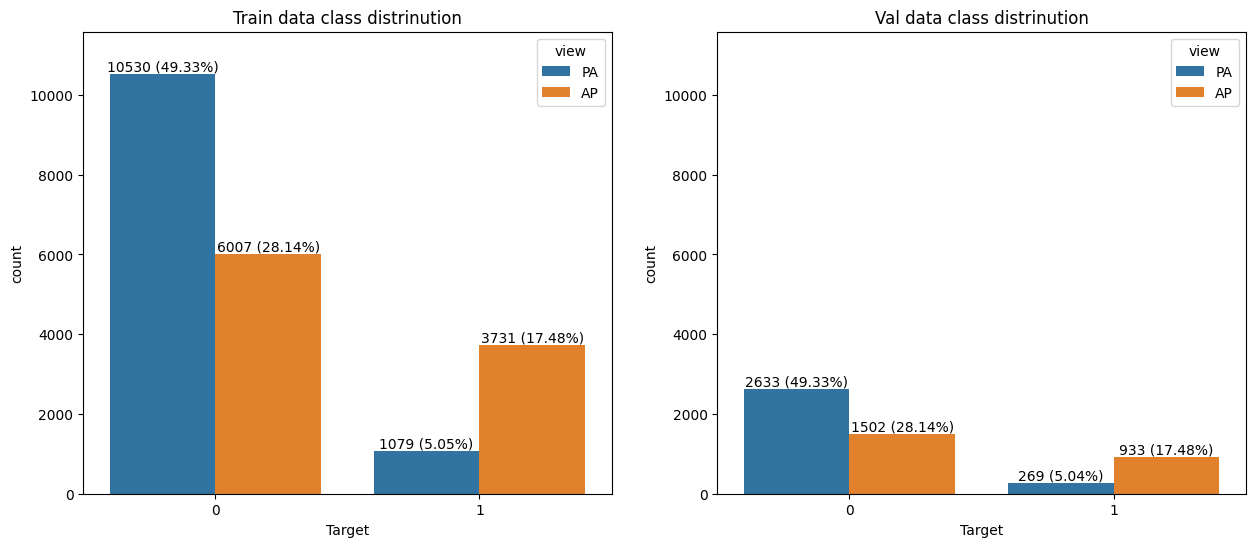

In [44]:
train_value_count = train_df.stratify_group.value_counts()
val_value_count = val_df.stratify_group.value_counts()

# Plot the distribution in graph and plot as percentage

fig, axes= plt.subplots(1, 2, figsize=(15, 6))


# bar graph 1 (Training Data)
train_stratify_count = train_df.groupby('Target')['view'].value_counts()
train_stratify_count = pd.DataFrame(data={'count': train_stratify_count.values}, index=train_stratify_count.index).reset_index()

bar1 = sns.barplot(data=train_stratify_count, x='Target', y='count', hue='view', ax=axes[0])
bar1_total = train_stratify_count['count'].sum()

for container in bar1.containers:
    bar1.bar_label(container, labels=[f'{int(h.get_height())} ({int(h.get_height())/bar1_total * 100 :.2f}%)' for h in container])
axes[0].set_title('Train data class distrinution')
axes[0].set_ylim(0, 1.1 * max(train_stratify_count['count']))



# bar graph 2 (Validation Data)
val_stratify_count = val_df.groupby('Target')['view'].value_counts()
val_stratify_count = pd.DataFrame(data={'count': val_stratify_count.values}, index=val_stratify_count.index).reset_index()

bar2 = sns.barplot(data=val_stratify_count, x='Target', y='count', hue='view', ax=axes[1])
bar2_total = val_stratify_count['count'].sum()

for container in bar2.containers:
    bar2.bar_label(container, labels=[f'{int(h.get_height())} ({int(h.get_height())/bar2_total * 100 :.2f}%)' for h in container])
    # bar2.bar_label(container, fmt='%d')
axes[1].set_title('Val data class distrinution')
axes[1].set_ylim(0, 1.1 * max(train_stratify_count['count']))


In [45]:
### We now have a stratitifed train and val dataset on the basis of Target class and view class.
### We see that the class is highly imbalanced. We will later address this with Image Augmentation after we format the data in YOLOv8 format.

### Format the data to pass into the YOLOv8

In [46]:
def dcm_to_jpg(dcm_path, save_path):
    '''
    Convert a DICOM (.dcm) file to a JPEG (.jpg) file and save it.

    This function reads a DICOM file from `dcm_path`, converts the pixel data
    to an image, and saves the image as a JPEG file at `save_path`.

    Args:
        dcm_path (str): File path of the input DICOM file.
        save_path (str): File path to save the output JPEG file.

    Returns:
        None
    '''
    save_path = Path(save_path)

    if not save_path.exists():
        dcm_data = dcmread(dcm_path)
        dcm_pixel_array = dcm_data.pixel_array
        image = Image.fromarray(dcm_pixel_array)
        image.save(save_path, 'JPEG')

In [47]:
# Create YOLO File format list

yolo_file_format = ['YOLO_format_data', ['images', 'labels', 'data.yaml'], ['train', 'val']]

# Create the YOLO file format directory
for x in range(2):
    for y in range(2):
        form_path = os.path.join(yolo_file_format[0], yolo_file_format[1][x], yolo_file_format[2][y])
        form_path = Path(form_path)
        form_path.mkdir(parents=True, exist_ok=True)

# # Create data.yaml file
yaml_file = Path(yolo_file_format[0]) / yolo_file_format[1][2]

# Content for the data.yaml file as required by the YOLO model
yaml_content = {
    'train': f'{yolo_file_format[1][0]}/{yolo_file_format[2][0]}',
    'val': f'{yolo_file_format[1][0]}/{yolo_file_format[2][1]}',
    'nc': 1,
    'names': ['pneumonia']
}

# write the content into the data.yaml file
with open(yaml_file, 'w') as file:
    yaml.dump(yaml_content, file)

In [48]:
# function to save all the train val images into the specified direcotry

def save_image(patient_Id, save_file_path):
    dcm_file_path = f'data/pneumonia_dataset/stage_2_train_images/{patient_Id}.dcm'
    save_file = save_file_path / f'{patient_Id}.jpg'
    dcm_to_jpg(dcm_path=dcm_file_path, save_path=save_file)

In [49]:
# Exmaple use case of Thread Pool (using Python ThreadPoolExecutor)

x = pd.Series([1, 2, 3, 4, 5])

with ThreadPoolExecutor() as executor:
    square = list(executor.map(lambda item: (item*item), x))

square

[1, 4, 9, 16, 25]

In [50]:
train_yolo_img = Path('YOLO_format_data/images/train')
val_yolo_img = Path('YOLO_format_data/images/val')

train_patientIds = train_df['patientId']
val_patientIds = val_df['patientId']

We will use Multi Threading to compute the "converting dcm data into image file" task faster

by doing this we creates a thread pool, meaning:

Multiple threads are launched.

Each thread runs a function (like save_image) independently.

Threads share the same memory space, so it’s lightweight for I/O-heavy tasks (like reading/writing files).

In [51]:
# executor.map returns a lazy iterator, so we wrap it in list() to force execution
# and allow tqdm to track progress as each task completes.

with ThreadPoolExecutor() as executor:
    # save all the train data images
    list(tqdm(executor.map(lambda Id: save_image(Id, save_file_path=train_yolo_img), train_patientIds), total=len(train_patientIds)))

    # save all the val data images
    list(tqdm(executor.map(lambda Id: save_image(Id, save_file_path=val_yolo_img), val_patientIds), total=len(val_patientIds)))

100%|██████████| 5337/5337 [00:00<00:00, 9707.80it/s] 


In [52]:
### Save all the labels(bbox data) into the txt file
train_yolo_txt = Path('YOLO_format_data/labels/train')
val_yolo_txt = Path('YOLO_format_data/labels/val')

def save_label(patientId, dataframe, save_file_path):

    """
    Save YOLO label file for a patient if pneumonia (Target == 1) is present.
    (will create a label file regardless of whether the label for that image exists or not)

    Skips if the file already exists. Writes normalized bbox coords in YOLO format:
    <class_id> <x_center> <y_center> <width> <height>

    Parameters:
    - patientId (str): ID of the patient/image
    - dataframe (pd.DataFrame): Data with 'Target', 'x', 'y', 'width', 'height'
    - save_file_path (Path or str): Directory to save the .txt file
    """
    
    save_file = Path(save_file_path) / f'{patientId}.txt'

    if not save_file.exists():

        data = dataframe[dataframe['patientId'] == patientId]        

        class_data = 0 if data['Target'].iloc[0].item() == 1 else None

        with open(save_file, 'w') as f:
            if class_data is not None:
                for _, row in data.iterrows():
                    x_center, y_center, width, height = row['x_center'], row['y_center'], row['width'], row['height']
                    f.write(f'{class_data} {x_center} {y_center} {width} {height}\n')

In [53]:
df_normalized_center

,patientId,x_center,y_center,width,height,Target,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,0.361816,0.333496,0.208008,0.370117,1,Lung Opacity
...,...,...,...,...,...,...,...
30222,c1ec14ff-f6d7-4b38-b0cb-fe07041cbdc8,0.291992,0.476074,0.222656,0.370117,1,Lung Opacity
30223,c1edf42b-5958-47ff-a1e7-4f23d99583ba,NaN,NaN,NaN,NaN,0,Normal
30224,c1f6b555-2eb1-4231-98f6-50a963976431,NaN,NaN,NaN,NaN,0,Normal
30225,c1f7889a-9ea9-4acb-b64c-b737c929599a,0.684082,0.552246,0.254883,0.336914,1,Lung Opacity


In [54]:
# save all the txt labels file
with ThreadPoolExecutor() as executor:
    # save all the train images txt label file 
    list(tqdm(executor.map(lambda Id: save_label(Id, df_normalized_center, save_file_path=train_yolo_txt), train_patientIds), total=len(train_df['patientId'])))

    # save all the val images txt label file
    list(tqdm(executor.map(lambda Id: save_label(Id, df_normalized_center, save_file_path=val_yolo_txt), val_patientIds), total=len(val_df['patientId'])))

100%|██████████| 5337/5337 [00:00<00:00, 9985.29it/s] 


In [55]:
# df[df['patientId'] == '0004cfab-14fd-4e49-80ba-63a80b6bddd6']
# df[df['patientId'] == '0a03fbf6-3c9a-4e2e-89ce-c7629ae43a27']


# target_id = '0a03fbf6-3c9a-4e2e-89ce-c7629ae43a27'
# filtered_df = df_normalized_center[df_normalized_center['patientId'] == target_id]

# df_normalized[df_normalized['patientId'] == '0a03fbf6-3c9a-4e2e-89ce-c7629ae43a27']

# df_normalized_center[df_normalized_center['patientId'] == '0a03fbf6-3c9a-4e2e-89ce-c7629ae43a27']

# 0 0.28759765625 0.7939453125 0.3681640625 0.25

# len(filtered_df), len(df_normalized_center)

### Data Augmentation
### To Address the Class Imbalance

In [56]:
train_sample = list(train_yolo_txt.glob('*.txt'))
val_sample = list(val_yolo_txt.glob('*.txt'))

len(train_sample), len(val_sample)

(35777, 8943)

In [57]:
# Check if there are any duplicates file in the sample
pd.Series(train_sample).is_unique, pd.Series(val_sample).is_unique

# Both returns true (True, True) means there are no duplicattes

(True, True)

In [58]:
### The pneumonia-absent(0) class data is way higher then the pneumonia-present(1) class....
### There is data class imabalnce and we will address and solve this with heavy augmentation of the peumonia-present(1) class images...and make both the class data to be of equal numbers....

# We will be using Albumentations library for image augmentaiton.....has built in support for bbox....the bbox data is also given when image are augmented 

In [59]:
# To find out what Data class need to be augmented and by how much to make the dataset more balanced

print('For Training Dataset:\n')

total = len(train_df)
positive = len(train_df[train_df.Target == 1])
negative = len(train_df[train_df.Target == 0])

print(f'Total Images: {total}')
print(f'Negative Images: {negative}')
print(f'Positive Images: {positive}')

ratio = negative/positive
print(f'\nNegative / Positive: {ratio}')
print(f'The ratio of Negative class to Positive class is: {ratio:.3f}. So we need to augment postive data class by {int(ratio)} times.\n')

print(f'After Augment Postive: {positive} + {positive} * 3 = {positive + positive * 3}')
print(f'After Augment Total: {negative} + {positive + positive * 3} = {negative + positive + positive * 3}')


print('____________________________________________________________')


print('\nFor Val Dataset:\n')

total = len(val_df)
positive = len(val_df[val_df.Target == 1])
negative = len(val_df[val_df.Target == 0])

print(f'Total Images: {total}')
print(f'Negative Images: {negative}')
print(f'Positive Images: {positive}')



print(f'After Augment Postive: {positive} + {positive} * 3 = {positive + positive * 3}')
print(f'After Augment Total: {negative} + {positive + positive * 3} = {negative + positive + positive * 3}')

For Training Dataset:

Total Images: 21347
Negative Images: 16537
Positive Images: 4810

Negative / Positive: 3.438045738045738
The ratio of Negative class to Positive class is: 3.438. So we need to augment postive data class by 3 times.

After Augment Postive: 4810 + 4810 * 3 = 19240
After Augment Total: 16537 + 19240 = 35777
____________________________________________________________

For Val Dataset:

Total Images: 5337
Negative Images: 4135
Positive Images: 1202
After Augment Postive: 1202 + 1202 * 3 = 4808
After Augment Total: 4135 + 4808 = 8943


In [60]:
# Build a pipeline to do the augmentation
train_yolo_img = Path('YOLO_format_data/images/train')
val_yolo_img = Path('YOLO_format_data/images/val')

In [61]:
transform1 = A.Compose([
    A.HorizontalFlip(p=1),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

transform2 = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.7),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.7, border_mode=0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

transform3 = A.Compose([
    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    A.GaussNoise(std_range=(0.02, 0.05), mean_range=(0.0, 0.0), p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))


C:\Users\ASUS\AppData\Local\Temp\ipykernel_47504\3708953765.py:3: DeprecationWarning: Parameter 'format' is deprecated and will be removed in a future version. Use 'bbox_format' instead. 'bbox_format' avoids shadowing the built-in 'format' function.
  ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))
c:\Users\ASUS\Desktop\Programming Projects\Pneumonia-Detection-Model\myenv\Lib\site-packages\albumentations\core\validation.py:132: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_47504\3708953765.py:8: DeprecationWarning: Parameter 'format' is deprecated and will be removed in a future version. Use 'bbox_format' instead. 'bbox_format' avoids shadowing the built-in 'format' function.
  ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_47504\3708953765.py:13:

In [62]:
# Build a pipeline to do the augmentation
train_yolo_img = Path('YOLO_format_data/images/train')
val_yolo_img = Path('YOLO_format_data/images/val')

def create_aug_data(patient_Id, image_dir, split):

    """
    Create augmented image and label data for a given patient ID.

    Parameters:
    - patient_Id (str): ID of the patient/image (without file extension).
    - image_dir (Path): Path to the directory containing the original .jpg images.
    - split (str): Dataset split; must be either "train" or "val".

    Notes:
    - Assumes `df` contains label data with bbox info.
    - Applies three predefined transforms to each image.
    - Augmented data is saved in YOLO format.
    """

    image_path = image_dir / f'{patient_Id}.jpg'
    image_pixel_array = cv2.imread(str(image_path))
    if image_pixel_array is None:
        print(f"Could not read image: {image_path}")
        return

    # get all the(if multiple present) bbox label data for that image
    label_data = df_normalized_center[df_normalized_center.patientId == patient_Id]
    bbox = label_data[['x_center', 'y_center', 'width', 'height']].values.tolist()
    if not bbox:
        print(f"No bbox found for: {patient_Id}")
        return
    

    img_dir = Path(f'YOLO_format_data/images/{split}')
    label_dir = Path(f'YOLO_format_data/labels/{split}')

    # we will apply 3 augmentations transform per image
    for index, transform in enumerate([transform1, transform2, transform3]):

        
        save_img_path = img_dir / f'{patient_Id}({index+1}).jpg'
        save_txt_path = label_dir / f'{patient_Id}({index+1}).txt'

        # what if the image exists but the label dosent....then it will not overwrite the image but it will overwrite the label which might not match the image
        # the following 'if staement' ensure the image and text files are in sync

        if not save_img_path.exists() or not save_txt_path.exists():
            augmented = transform(image=image_pixel_array, bboxes=bbox, class_labels=[0]*len(bbox))
            image_array = augmented['image']
            image = Image.fromarray(image_array)
            image.save(save_img_path, 'JPEG')

            with open(save_txt_path, 'w') as f:
                for label, cls in zip(augmented['bboxes'], augmented['class_labels']):
                    f.write(f'{int(cls)} {label[0]} {label[1]} {label[2]} {label[3]}\n')
            #         # this is same as writing
            #         # f.write(f'{class_data} {x_center} {y_center} {width} {height}\n')

In [63]:
# Notes on re-running the data Augmentation code-cell
# ─────────────────────────────────────────────
# Augmented files are saved with deterministic names (e.g. 'patient_001(1).jpg'),

# The `create_aug_data` function skips a pair if both the image AND label already exist.
# this line of code `if not save_img_path.exists() or not save_txt_path.exists():`
# So re-running will never duplicate files.
#
# The only edge case: if one file from a pair is missing, both are rewritten together to keep images and labels in sync.

In [64]:
train_aug_id = train_df[train_df.Target == 1].patientId
val_aug_id = val_df[val_df.Target == 1].patientId
len(train_aug_id), len(val_aug_id)

(4810, 1202)

In [65]:
### Augmentation Data Creation

train_func = partial(create_aug_data, image_dir=train_yolo_img, split='train')
val_func = partial(create_aug_data, image_dir=val_yolo_img, split='val')

with ThreadPoolExecutor() as executor:
    list(tqdm(executor.map(train_func, train_aug_id), total=len(train_aug_id)))
    list(tqdm(executor.map(val_func, val_aug_id), total=len(val_aug_id)))

100%|██████████| 1202/1202 [00:10<00:00, 119.63it/s]


### Print some of the augmented images with bbox for visualziation

In [66]:
def print_augmented_sample(aug_ids, img_dir, label_dir, rows=3, cols=3, seed=None):
    """
    Visualize randomly sampled augmented images with their bounding boxes.

    Reads JPG images and YOLO-format .txt label files directly - no dependency on the original df or DICOM files.
    
    YOLO label format: <class_id> <x_center> <y_center> <width> <height>
    All values normalized 0-1. This function converts them back to pixel coords for display.

    Args:
        aug_ids     : list of augmented file prefix strings e.g. 'abc123(1)'
        img_dir     : Path to directory containing augmented .jpg images
        label_dir   : Path to directory containing augmented .txt label files
        rows, cols  : Grid dimensions
        seed        : Random seed for reproducibility (None = random each call)
    """

    if seed is not None:
        random.seed(seed)

    n = rows * cols

    sample_ids = random.sample(aug_ids, min(n, len(aug_ids))) # min(n, len(aug_ids)) -> chooses smaller between 'n' and 'len(aug_ids)'. prevents errors if 'n' is larger then the list size of 'aug_ids'

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    for idx, file_id in enumerate(sample_ids):
        ax = axes[idx]

        img_path = Path(img_dir) / f'{file_id}.jpg'
        label_path = Path(label_dir) / f'{file_id}.txt'


        # ________________________________________
        # Load Image
        if not img_path.exists():
            ax.text(0.5, 0.5, f'Image not found:\n{file_id}', ha='center', va='center', transform=ax.transAxes, color='red', fontsize=8)
            ax.axis('off')
            continue

        img = np.array(Image.open(img_path).convert('L')) # grayscale
        img_h, img_w = img.shape

        ax.imshow(img, cmap='gray')
        ax.axis('off')

        # _________________________________________
        # Load and draw the bboxes
        if label_path.exists() and label_path.stat().st_size > 0:
            with open(label_path, 'r') as f:
                lines = f.read().strip().splitlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                cls, x_c, y_c, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

                # Convert YOLO normalized -> pixel coords for Rectangle
                x_min = (x_c - (w / 2)) * img_w
                y_min = (y_c - (h / 2)) * img_h
                box_w = w * img_w
                box_h = h * img_h

                rect = patches.Rectangle(
                    (x_min, y_min), box_w, box_h, linewidth=2, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)

            ax.set_title(f'{file_id}\n{len(lines)} bbox(es)', fontsize=7, color='red')
        else:
            # Empty label = no pneumonia (negative augmented image - shouldn't happen since we have only augmented `Target = 1`, but good practise to handle)
            ax.set_title(f'{file_id}\nno label', fontsize=7, color='green')

    
    # Hide unused subplots
    for j in range(len(sample_ids), rows * cols):
        axes[j].axis('off')

    plt.suptitle('Augmented Images - Visual Label Check', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


In [67]:
# Build full list of augmented file prefixes
# Format: '{patientId}(1)', '{patientId}(2)', '{patientId}(3)'
train_aug_prefixes = [f'{pid}({i})' for pid in train_aug_id for i in range(1, 4)]
val_aug_prefixes = [f'{pid}({i})' for pid in val_aug_id for i in range(1, 4)]

print(f'Total augmented train files: {len(train_aug_prefixes)}') # should be len(train_aug_id) * 3
print(f'Total augmented val files: {len(val_aug_prefixes)}')

Total augmented train files: 14430
Total augmented val files: 3606


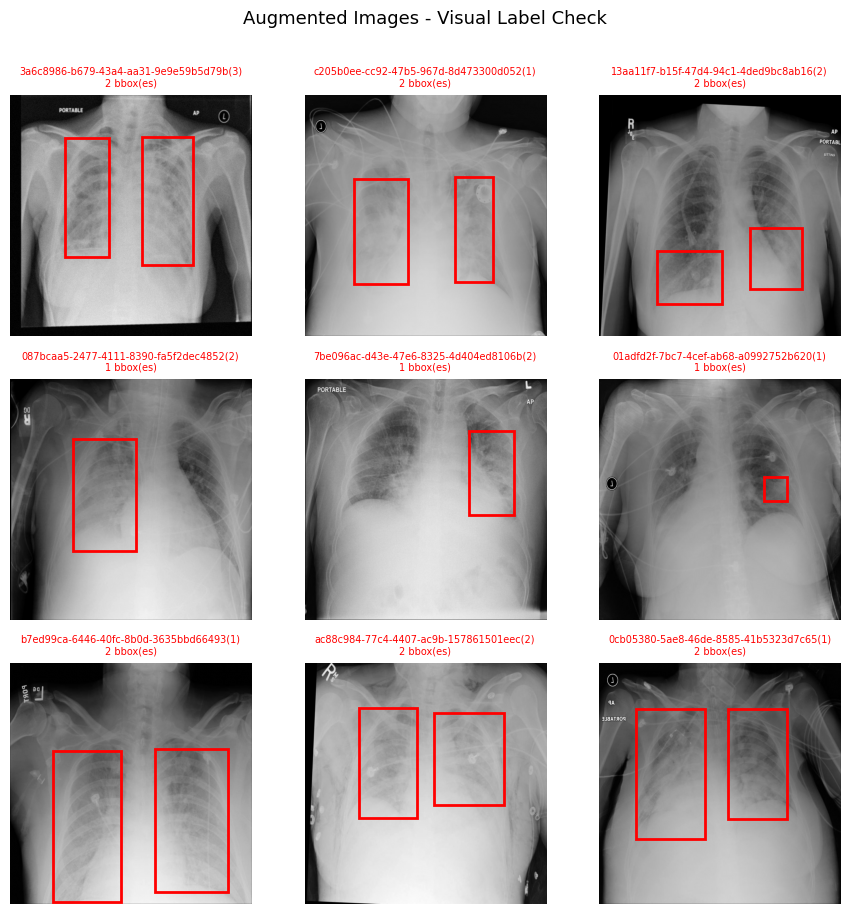

In [68]:
# Visualization of 3x3 grid of augmented training images
print_augmented_sample(aug_ids=train_aug_prefixes, img_dir=train_yolo_img, label_dir=train_yolo_txt, rows=3, cols=3, seed=None)

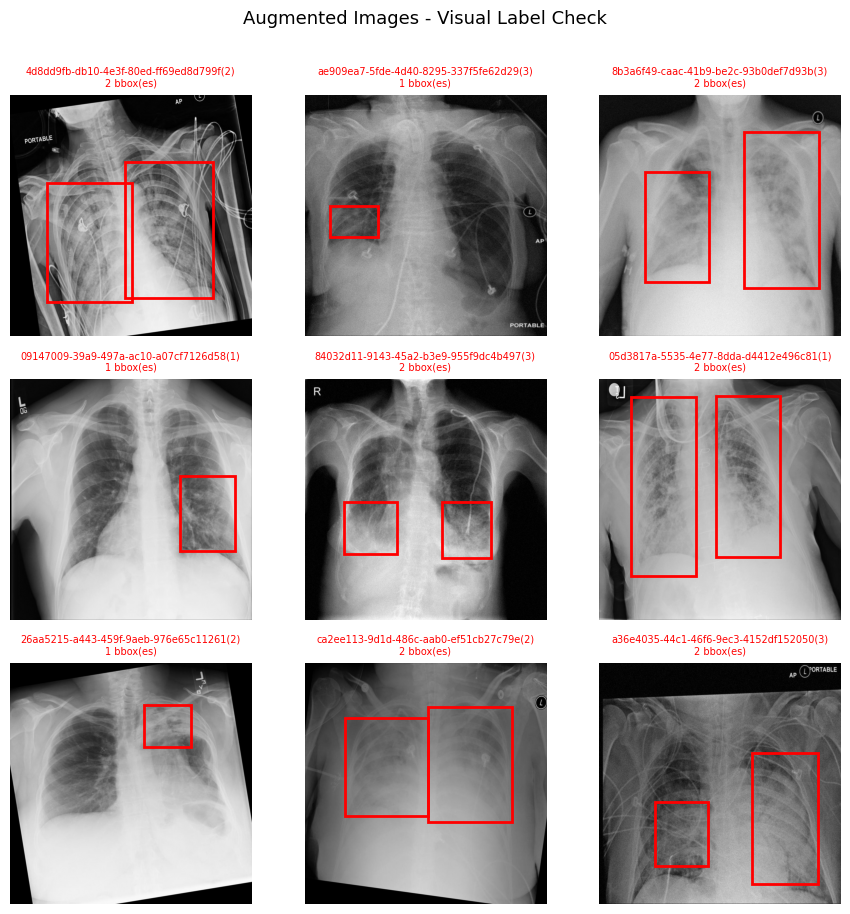

In [69]:
# Visualization of 3x3 grid of validation augmented images
print_augmented_sample(aug_ids=val_aug_prefixes, img_dir=val_yolo_img, label_dir=val_yolo_txt, rows=3, cols=3, seed=None)

In [70]:
# For Training Dataset:

# Total Images: 21347
# Negative Images: 16537
# Positive Images: 4810
# After Augment Postive: 4810 + 4810 * 3 = 19240
# After Augment Total: 16537 + 19240 = 35777
# ____________________________________________________________

# For Val Dataset:

# Total Images: 5337
# Negative Images: 4135
# Positive Images: 1202
# After Augment Postive: 1202 + 1202 * 3 = 4808
# After Augment Total: 4135 + 4808 = 8943

In [71]:
# get all the txt(label) files form the train and val dataset label directory
train_sample = list(train_yolo_txt.glob('*.txt'))
val_sample = list(val_yolo_txt.glob('*.txt'))

len(train_sample), len(val_sample)

(35777, 8943)

In [72]:
# Check if there are any duplicates file in the sample
pd.Series(train_sample).is_unique, pd.Series(val_sample).is_unique

(True, True)

In [73]:
# Plot a graph of data distribution to show that the class imbalance has been addressed.....


train_abs_file = 0
train_pres_file = 0
for path in tqdm(train_sample):
    # Checks if the content of the file is zero/null
    if os.stat(path).st_size == 0:
        train_abs_file+=1
    else:
        train_pres_file+=1


val_abs_file = 0
val_pres_file = 0
for path in tqdm(val_sample):
    if os.stat(path).st_size == 0:
        val_abs_file+=1
    else:
        val_pres_file+=1


print(train_abs_file, train_pres_file)
print(val_abs_file, val_pres_file)
train_abs_file, train_pres_file, val_abs_file, val_pres_file

100%|██████████| 8943/8943 [00:01<00:00, 6799.45it/s]

16570 19207
4141 4802


(16570, 19207, 4141, 4802)

In [74]:
data = [
    ('train', 0, train_abs_file),
    ('train', 1, train_pres_file),
    ('val', 0, val_abs_file),
    ('val', 1, val_pres_file)
]

rand_df = pd.DataFrame(data=data, columns=['data type', 'class', 'count'])
rand_df

,data type,class,count
0,train,0,16570
1,train,1,19207
2,val,0,4141
3,val,1,4802


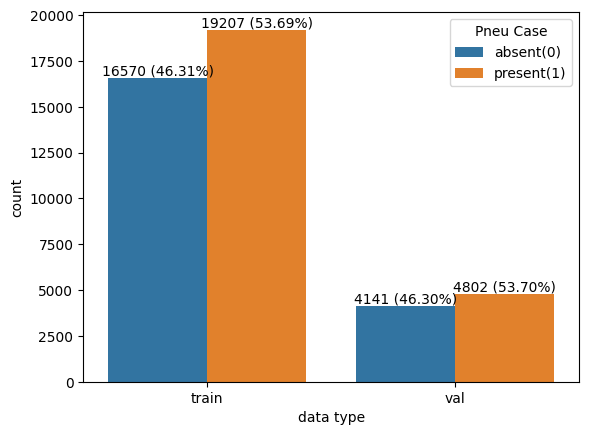

In [75]:
# Plot a graph of data distribution to show that the class imbalance has been addressed.....


bar = sns.barplot(data=rand_df, x='data type', y='count', hue='class')
total = rand_df.groupby('data type')['count'].sum()

for container in bar.containers:
 
    bar.bar_label(container, labels=[f'{int(h.get_height())} ({int(h.get_height())/total.iloc[index] * 100 :.2f}%)' for index, h in enumerate(container)])

handles, labels = bar.get_legend_handles_labels()

plt.legend(handles=handles, labels=['absent(0)', 'present(1)'], title='Pneu Case')


#### EDA is completed and the data has been formatted in YOLO format
#### Now fine tune the model on this formatted data

In [67]:
# Instanciate the YOLO model
import torch
from ultralytics import YOLO


device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

model = YOLO("yolo26m.pt")

In [ ]:
# Run a training by defining the hyperparameters for the model training.

train_results = model.train(
    data='YOLO_format_data/data.yaml',
    epochs=50,
    imgsz=1024,
    batch=8,
    name='yolo26m_medical_imaging_f_50',
    optimizer="AdamW",
    lr0=0.0005,    # When fine-tuning on a custom dataset, consider to keep the learning rate lower than the default to prevent large updates to the pretrained weights. # Smaller learning rates like 0.0005 or 0.0001 are often used for fine-tuning to allow the model to gradually adapt to the new dataset.
    patience=20    # early stopping if validation doesn't improve # If there is no improvement for a number of epochs (equal to patience), it will halt the training early to save time and prevent overfitting.
)

In [ ]:
# Continue training the model if the model training was halted/stopped before the completion
from ultralytics import YOLO

# # Instanciate a new training on the best of the trained model
# model = YOLO('runs/detect/medical_imaging_v4/weights/best.pt')
# model.train(data='YOLO_format_data/data.yaml', epochs=50, project='runs/detect', name='medical_imaging_50_epo')


# Continue Training from where left
# model = YOLO('runs/detect/medical_imaging_50_epo/weights/last.pt')
model = YOLO('runs/detect/medical_imaging_v4/weights/last.pt')
model.train(resume=True)

In [ ]:
### NOTE: Details about instantiating the model training.

# We have follwoing options(in terms of model size) for loading a pretrained YOLO26 model

#   "yolo26n.pt"  (nano, fastest)
#   "yolo26s.pt"  (small)
#   "yolo26m.pt"  (medium)
#   "yolo26l.pt"  (large)
#   "yolo26x.pt"  (extra large)

from ultralytics import YOLO
model = YOLO("yolo26m.pt")  # we can adjust the model to size appropriate for our dataset


# Fine-tune / Train on out custom dataset
train_results = model.train(
    data="YOLO_format_data/data.yaml",  # path to our dataset config
    epochs=100,                         # number of training epochs
    imgsz=1024,                         # training image resolution (higher resolution helps small object detection)
    batch=16,                           # batch size (consider to reduce if GPU memory is limited)
    device=0,                           # GPU device index (or "cpu")
    optimizer="AdamW",                  # optimizer for fine-tuning
    lr0=0.0005,                         # initial learning rate
    patience=20                         # early stopping patience
)


# Validation of the trained model
val_metrics = model.val()


# Inference on a sample image
results = model("path/to/test_image.jpg")
results[0].show()  # display predicted detections


# Export the fine-tuned model to ONNX/TensorRT/CoreML, etc.
export_path = model.export(format="onnx")
print(f"Model exported at: {export_path}")


### Evaluate the model results and make necessary changes

In [69]:
# Lets evaluate the yolo8n model that was trained. with about 0.25 map@50 and 0.1 map@50-95:step size of 5

from ultralytics import YOLO

model = YOLO('runs/detect/medical_imaging_v4/weights/best.pt')

# Validate the model in terms of differnt scores
# val_metrics = model.val()

## Run inference on one of the images form the trained model

In [ ]:
# The pixel data is in range of 0 to 255. We normalize the pixel data of image in range 0 to 1 which is required to pass into the YOLO model for inference
# For that we create a transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Define a function that run inferences on images and outputs the images with predicted label vs actual label

def run_inference(samp_num, inf_model):
    pos_inference_sample_ids = df[df['Target'] == 1].sample(samp_num, random_state=None)['patientId'].reset_index(drop=True)

    fig, axes = plt.subplots(samp_num, 2, figsize=(7, samp_num*5)) # figsize scales with samp_num

    axes = axes.flatten()

    

    for i, patient_id in enumerate(pos_inference_sample_ids):

        sample_image_path = Path(f'data/pneumonia_dataset/stage_2_train_images/{patient_id}.dcm')
        dcm_data = dcmread(sample_image_path)
        pixel_data = dcm_data.pixel_array

        

        # Normalize the pixel data in 0 to 1 range using transformer
        image_data = transform(pixel_data)

        ## Reformat the dimension of the data to properly pass through plt.imshow()
        
        # Convert the image data shape in (Batch, Height, Width) to (Batch, Color Channel, Height, Width)

        # NOTE: in_channels = 1 # since the image is grayscale the in_channels will be 1
        # Before passing the image into the YOLO model it should be in the shape (Batch, Color Channel, Height, Width)
        
        image_data_inf = image_data.unsqueeze(dim=1)
        # unsqueeze dim=1 for color channel which is 1 (Greyscale image)

        image_data_inf = image_data_inf.repeat(1, 3, 1, 1)


        image_data_per = image_data.permute(1, 2, 0)


        # We have the patient id.
        # search for all the data of that patient id in the df
        all_labels = df[df['patientId'] == patient_id]


        results = inf_model(image_data_inf)
        model_output = results[0].plot()

        # results[0].boxes # gives out the bbox data (if any)
        # results[0].show() # outputs image with bbox (if any)
        # Print out the model prediction results and actual results


        # Predicted labels from model
        axes[(2*i)].imshow(model_output, cmap='gray')
        axes[(2*i)].set_title(f'Predicted Label')
        # axes[(2*i)].set_title(f'Predicted Label - {patient_id}')
        axes[(2*i)].axis(False)

        # Actual label from the data labels
        axes[(2*i+1)].imshow(image_data_per, cmap='gray')
        axes[(2*i+1)].set_title(f'Actual Label')
        # axes[(2*i+1)].set_title(f'Actual Label - {patient_id}')
        axes[(2*i+1)].axis(False)


        # Draw the actual bbox label data over the image
        for j in range(len(all_labels)):
            col_data = all_labels.iloc[j]
            
            x, y, width, height = col_data.x, col_data.y, col_data.width, col_data.height
            rect = patches.Rectangle((x, y), width, height, facecolor='none', edgecolor='red', lw=2)
            axes[(2*i+1)].add_patch(rect)

    plt.tight_layout()
    plt.show()



0: 1024x1024 1 pneumonia, 142.9ms
Speed: 4.4ms preprocess, 142.9ms inference, 73.8ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 33.9ms
Speed: 3.9ms preprocess, 33.9ms inference, 22.3ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 30.8ms
Speed: 4.3ms preprocess, 30.8ms inference, 18.0ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 25.6ms
Speed: 4.1ms preprocess, 25.6ms inference, 17.8ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 38.6ms
Speed: 4.6ms preprocess, 38.6ms inference, 18.1ms postprocess per image at shape (1, 3, 1024, 1024)


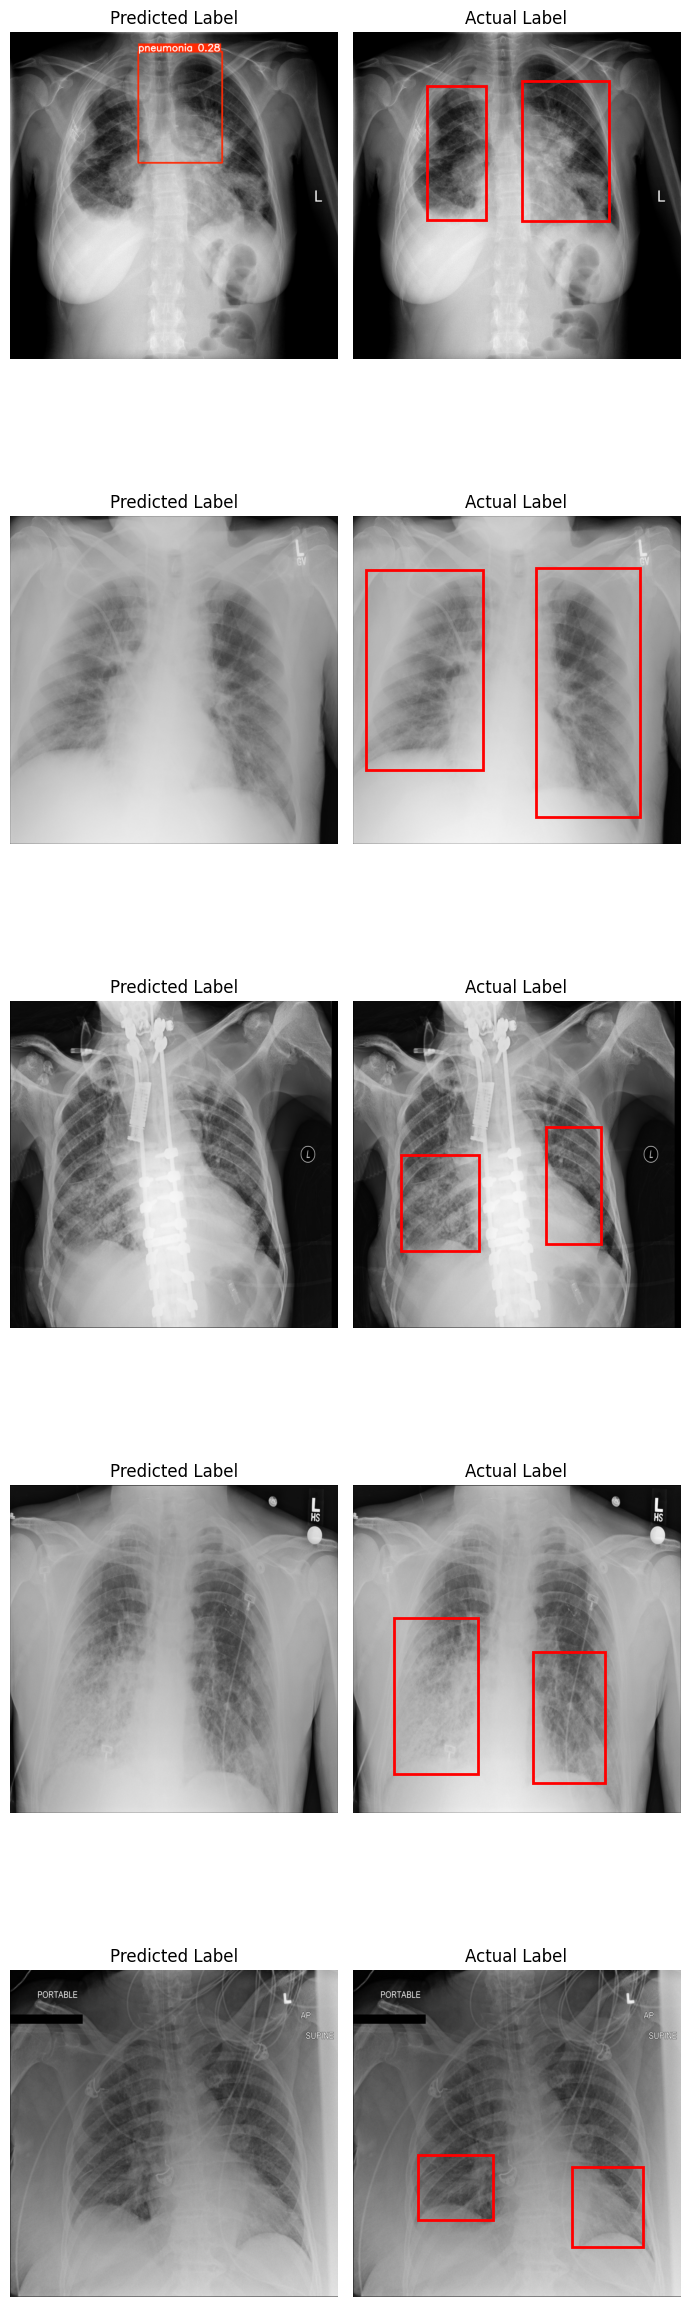

In [71]:
run_inference(samp_num=5, inf_model=model)

In [354]:
# NOTE: 
# df -> x, y, width, heigth
# df_normalized -> x, y, width, heigth (but normalized)
# df_normalized_center -> x_center, y_center, width, heigth (normalized and center)

### Model evaluation metrics.......and graphs to evaluate the model performance post training....

# TO DO: 



###### Use Grad-CAM or heatmap visualization to interpret model focus.

###### Implement data augmentation early to reduce overfitting.

###### Downsample images to 224×224 or 256×256 to save resources without performance loss.



###### Use sklearn train test split to split the data into train and validation set

###### Also address the class imbalance

###### More EDA on the Data---graphs and tables to show the data stuff and training decision made based on that

###### Image Augmentation to increase the data samples



###### Train the model again after completing all of the above steps for up to 100 epochs
###### In the mean time also look for more powerful computer to train the model on


###### Heatmap after the model has been trained.....to see where the model mostly localizes its predication ....and comapre it with the initial heatmap of the label bbox data


###### PA and AP view also plays a huge role in how the model will train.....(`FUTURE CONSIDERATION`: we can pass the data into the model giving it context of the AP and PA view so it has this `view` context aware)

Take the model we have trained now(the best one).....run inference on it and get the return bbox data from it....and plot the heatmap...the heatmap of our trained model (map50 = 0.25) on the final prediciton of the model

For post model evaluation heatmap

Only add to the heatmap when the confiednce score in greater then a ceratin threshold
if confidence_score > threshold:
* .....
* .....
* heatmap[y_min:y_max, x_min:x_max] += 1

Also dont add 1 but rather add the confidence score
if confidence_score > threshold:
* .....
* .....
* heatmap[y_min:y_max, x_min:x_max] += confidence_score


Why we add a confidence score......

If you just add +1 for every predicted box above the threshold, all boxes are treated equally — even if one is 51% confident and another is 99%. But intuitively:

A 99% confidence box should contribute more to the heatmap.

A 51% confidence box might be a borderline false positive — it should contribute less.

By adding the confidence score:

Areas where the model consistently predicts with high confidence will "light up" more.

You get a more nuanced and informative visualization.

### Here are some tips this time around to improve the result with the model
1. Verify Label Quality
* Visualize random samples with bounding boxes.
* Check for tight boxes, accurate positioning, and no false positives.
* Ensure multi-lesion images have multiple boxes.

2. Balance Your Dataset
* Check for class imbalance (e.g., many normal X-rays vs few pneumonia).
* Consider oversampling pneumonia cases.
* Optionally, downsample normal cases or balance batches.

3. Use Image-Level Metadata
* Use DICOM metadata (e.g., ViewPosition, PatientAge) to filter or group data.
* Prefer consistent views (e.g., only PA or AP) to avoid confusing patterns.

4. Data Augmentation
* Use or customize YOLOv8’s built-in augmentations.
* Apply flips, scaling, blur, brightness, and contrast adjustments.
* More aggressive augmentation can help detect small or subtle patterns.

5. Try Larger YOLOv8 Models
* Instead of yolov8n, try yolov8s, yolov8m, or yolov8l depending on GPU capacity.
* Larger models capture more features and improve accuracy.

6. Use Mosaic Augmentation
* Enabled by default in YOLOv8.
* Especially effective for small and sparse objects like pneumonia patches.
* Make sure it's not accidentally turned off.

7. Train Longer & Use Cosine Learning Rate
* Train for 100+ epochs if loss hasn’t plateaued.
* Use a cosine LR schedule for smoother convergence.
* Example: scheduler='cosine', lr0=0.001, lrf=0.01.

8. Evaluate on a Clean Validation/Test Set
* Use a separate, representative validation/test split.
* Run model.val() or model.predict() to evaluate performance.
* Avoid leakage between training and test sets.

9. Filter Out Bad or Corrupt Images
* Check for black images, invalid DICOMs, or low-contrast junk data.
* Remove lateral views or mislabeled cases, if any.

10. (Optional) Handle Grayscale Input Smartly
* X-rays are grayscale, but YOLO expects 3-channel RGB.
* Convert grayscale to 3-channel by duplicating channels.
* Advanced: Modify model input layer to accept 1-channel images (not necessary, but possible).

In [ ]:
### FOR FUTURE: If u wanna expand the dataset to finetune the model (more dataset to finetune the model)

# Scour internet to possibly find more pneumonia data that u can use to train your model....
# Following are some of the publicly available dataset that contain pnuemonia related data.......future consideration to combine them with the RSNA Pnuemonia dataset.....




# NIH ChestX-ray14
# Large public dataset with multiple disease labels including pneumonia. Mostly image-level labels but some bounding boxes available.

# CheXpert (Stanford)
# Very large, labeled chest X-ray dataset. Has uncertain labels, so careful handling needed.

# MIMIC-CXR
# Huge dataset with chest X-rays and rich metadata from ICU patients. Requires credentialed access.

# COVID-19 X-ray datasets
# Include pneumonia cases (viral pneumonia). Useful for broader pneumonia modeling.

# https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data

🔬 4. Use Synthetic Data (Optional Advanced)
If your model still struggles with generalization, consider:

* GANs to generate pneumonia-like lungs (requires extra work)

* Copy-Paste augmentation: Cut pneumonia areas from positive images and paste them on negatives (experimental, works better with masks)

-----------------------------------------------


🧪 3. (Advanced) Synthetic Data
* Generating pneumonia-like images using GANs or Copy-Paste is powerful, but:

    * It’s research-level

    * Needs masks or well-localized regions

    * Takes time and experimentation

✔️ High risk–high reward
✘ Might not be necessary for RSNA

it does matter what kind of augmentation you apply, especially for object detection on a medical dataset like RSNA Pneumonia Detection.

Here's a breakdown:

✅ Augmentations That Help:
These simulate realistic variations in X-rays without breaking the medical meaning:

Horizontal flip (A.HorizontalFlip)
✅ Safe and common. Lungs are symmetric; flipping doesn’t usually distort meaning.

Small rotations / shifts / scales (A.ShiftScaleRotate)
✅ Slight changes are okay — simulate different patient positioning.
⚠️ Avoid large shifts/rotations that could move pneumonia out of frame.

Brightness/contrast changes (A.RandomBrightnessContrast)
✅ Good for robustness to exposure variation across machines.

Gaussian noise or blur (light)
✅ Adds robustness to imaging artifacts, but use lightly.

⚠️ Augmentations That Can Hurt:
Vertical flip
🚫 Not realistic — lungs don’t appear upside down in valid chest X-rays.

Cutout / GridDropout
⚠️ Risky unless used carefully; might obscure critical pneumonia areas.

Heavy rotation (>15°), scale, crop
🚫 Can make the bounding boxes invalid or cut out the pneumonia region.

Color jitter / hue / saturation
🚫 Medical images are grayscale — color transforms don’t apply.